## Inicio del código EDA

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
data = pd.read_pickle('../data/processed/clean_data.pkl')
data.dtypes

InvoiceNo                 str
StockCode                 str
Description               str
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
TotalPrice            float64
dtype: object

In [21]:
# Basic statistics
# sum of TotalPrice
print("Sum of TotalPrice:", data["TotalPrice"].sum())
# mean of TotalPrice
print("Mean of TotalPrice:", data["TotalPrice"].mean())
# median of TotalPrice
print("Median of TotalPrice:", data["TotalPrice"].median())
# standard deviation of TotalPrice
print("Standard Deviation of TotalPrice:", data["TotalPrice"].std())
# count of length of TotalPrice
print("Count of TotalPrice:", data["TotalPrice"].count())

Sum of TotalPrice: 8887208.894000001
Mean of TotalPrice: 22.631499735161402
Median of TotalPrice: 12.45
Standard Deviation of TotalPrice: 311.09922433480364
Count of TotalPrice: 392692


C:\Users\eluni\AppData\Local\Temp\ipykernel_8932\2296067620.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Mes')


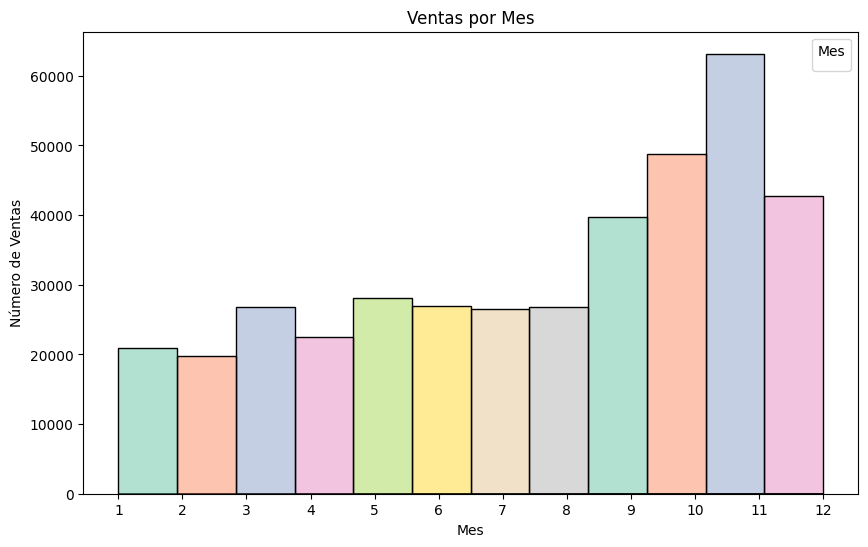

In [22]:
# Genera un histograma de ventas por mes diferenciado los meses por colores
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['Month'] = data['InvoiceDate'].dt.month
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='Month', hue='Month', palette='Set2', bins=12, kde=False)
plt.title('Ventas por Mes')
plt.xlabel('Mes')
plt.ylabel('Número de Ventas')
plt.xticks(range(1, 13))
plt.legend(title='Mes')
plt.show()

C:\Users\eluni\AppData\Local\Temp\ipykernel_8932\3319026133.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Set2')


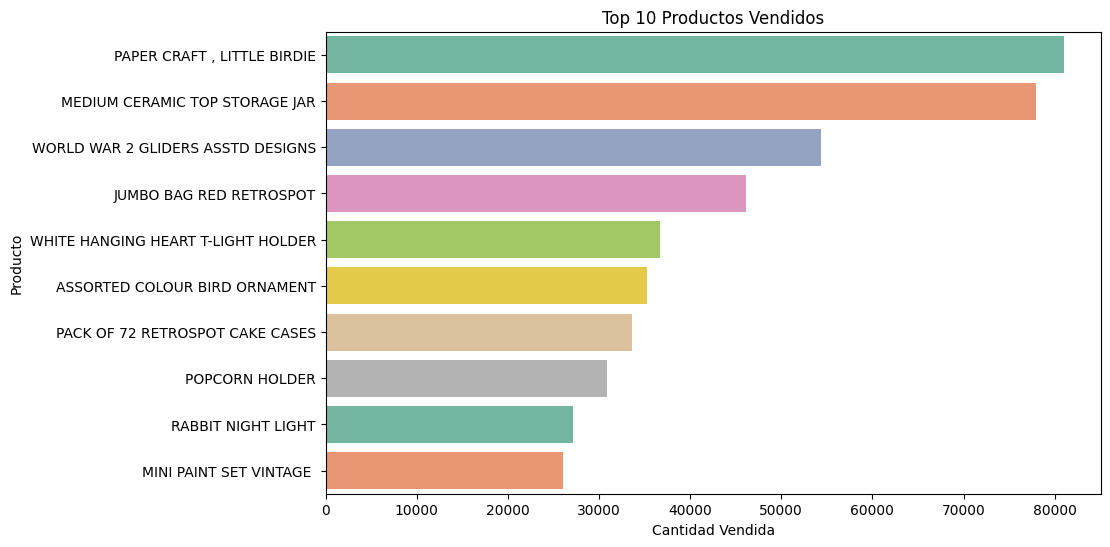

In [23]:
# Genera un grafico para ver top productos vendidos
top_products = data.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, palette='Set2')
plt.title('Top 10 Productos Vendidos')
plt.xlabel('Cantidad Vendida')
plt.ylabel('Producto')
plt.show()


C:\Users\eluni\AppData\Local\Temp\ipykernel_8932\1163163403.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_sales.values, y=country_sales.index, palette='Set2')


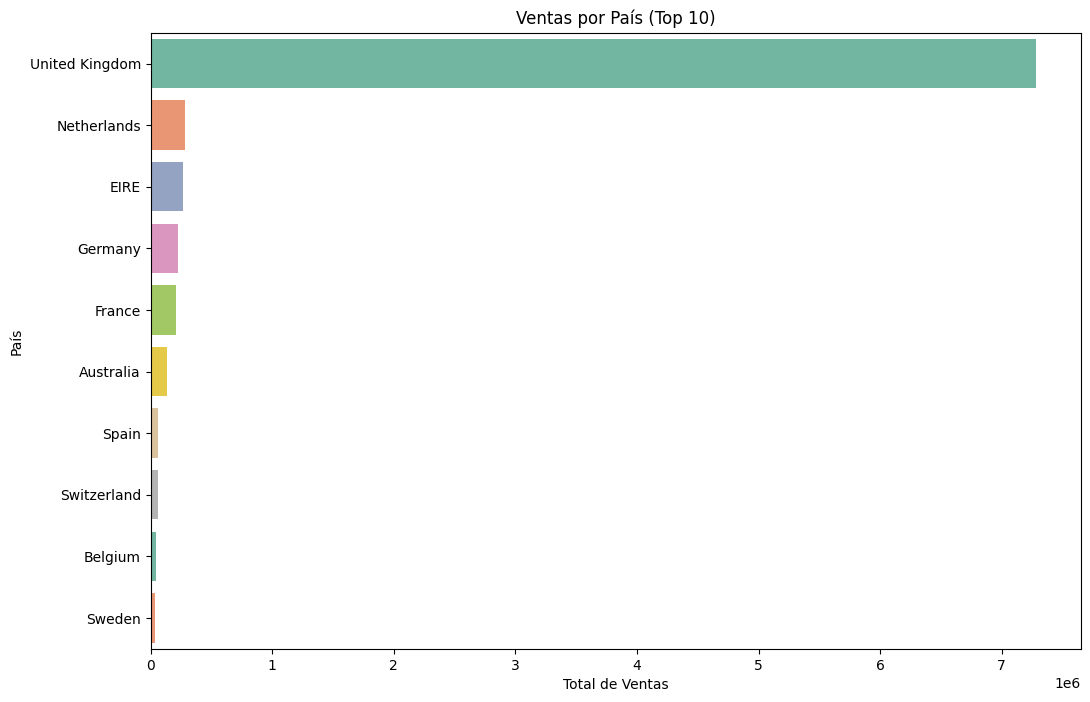

In [24]:
# Genera un gráfico de barras de ventas por país
plt.figure(figsize=(12, 8))
country_sales = data.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=country_sales.values, y=country_sales.index, palette='Set2')
plt.title('Ventas por País (Top 10)')
plt.xlabel('Total de Ventas')
plt.ylabel('País')
plt.show()


C:\Users\eluni\AppData\Local\Temp\ipykernel_8932\2491311083.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette='Set2')


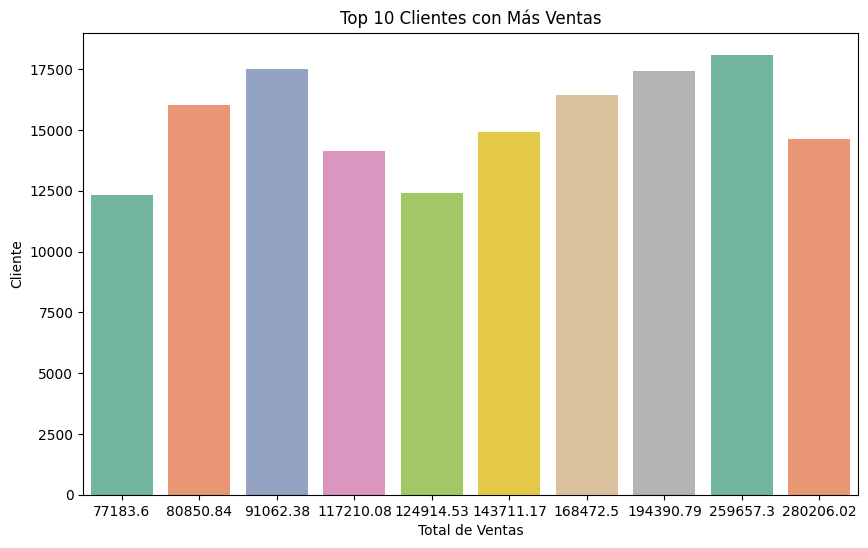

In [25]:
# top 10 clientes con más ventas
top_customers = data.groupby('CustomerID')['TotalPrice'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='Set2')
plt.title('Top 10 Clientes con Más Ventas')
plt.xlabel('Total de Ventas')
plt.ylabel('Cliente')
plt.show()

C:\Users\eluni\AppData\Local\Temp\ipykernel_8932\479698224.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers_freq.values, y=top_customers_freq.index, palette='Set2')


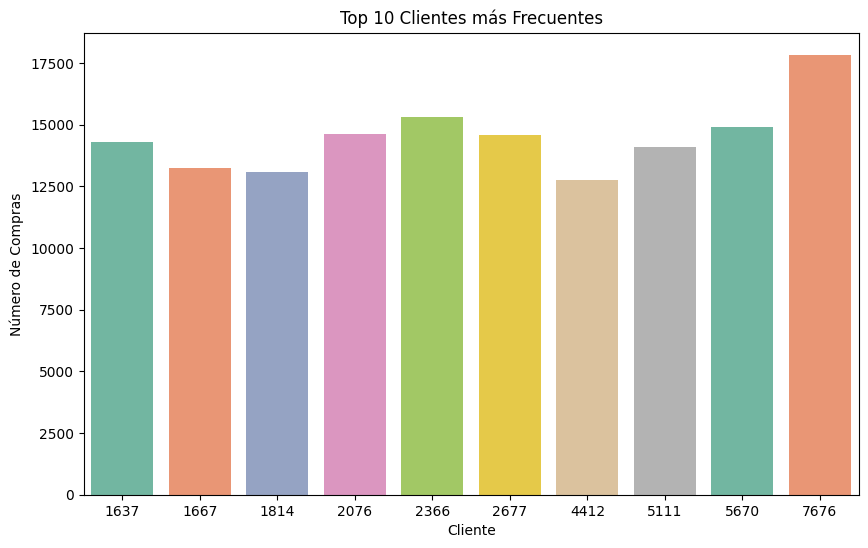

In [26]:
# Genera un gráfico que muestre los clientes mas frecuentes
top_customers_freq = data['CustomerID'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_customers_freq.values, y=top_customers_freq.index, palette='Set2')
plt.title('Top 10 Clientes más Frecuentes')
plt.xlabel('Cliente')
plt.ylabel('Número de Compras')
plt.show()


In [27]:
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data["TotalPrice"].describe()

count    392692.000000
mean         22.631500
std         311.099224
min           0.001000
25%           4.950000
50%          12.450000
75%          19.800000
max      168469.600000
Name: TotalPrice, dtype: float64

In [28]:
import pandas as pd
from datetime import datetime

# Fecha de referencia (última fecha del dataset)
snapshot_date = data["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = data.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                  # Frequency
    "TotalPrice": "sum"                                      # Monetary
})

rfm.rename(columns={
    "InvoiceDate": "Recency",
    "InvoiceNo": "Frequency",
    "TotalPrice": "Monetary"
}, inplace=True)

print(rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
12346.0         326          1  77183.60
12347.0           2          7   4310.00
12348.0          75          4   1797.24
12349.0          19          1   1757.55
12350.0         310          1    334.40


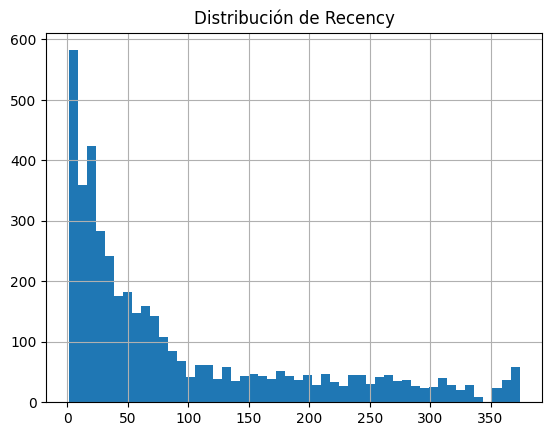

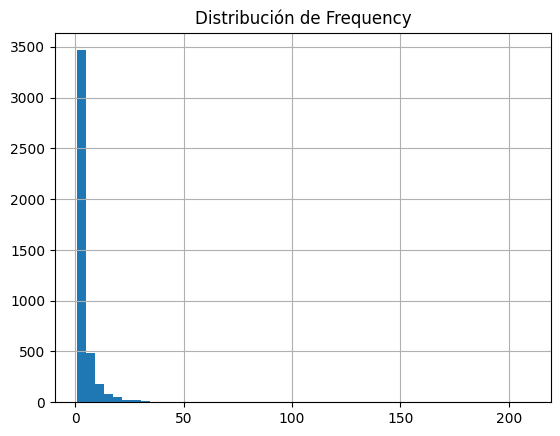

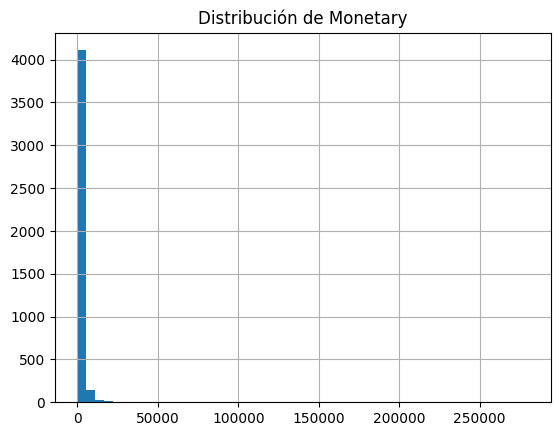

In [29]:
import matplotlib.pyplot as plt

# Recency
rfm["Recency"].hist(bins=50)
plt.title("Distribución de Recency")
plt.show()

# Frequency
rfm["Frequency"].hist(bins=50)
plt.title("Distribución de Frequency")
plt.show()

# Monetary
rfm["Monetary"].hist(bins=50)
plt.title("Distribución de Monetary")
plt.show()

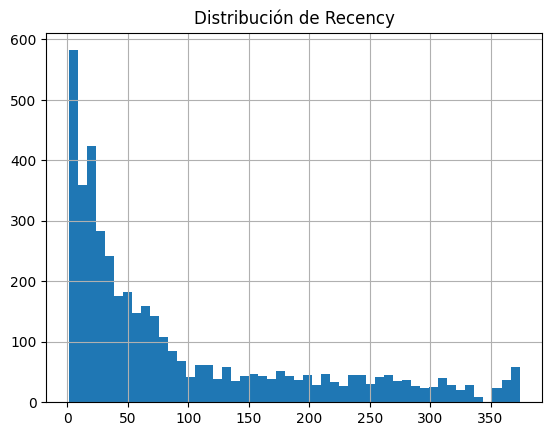

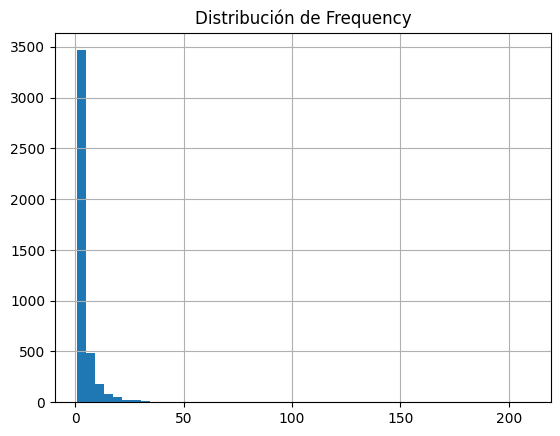

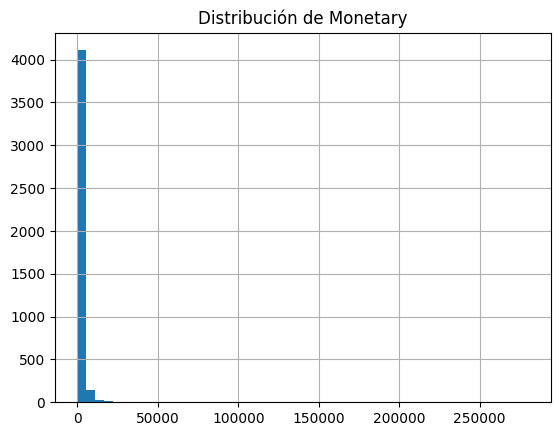

In [30]:
import matplotlib.pyplot as plt

# Recency
rfm["Recency"].hist(bins=50)
plt.title("Distribución de Recency")
plt.show()

# Frequency
rfm["Frequency"].hist(bins=50)
plt.title("Distribución de Frequency")
plt.show()

# Monetary
rfm["Monetary"].hist(bins=50)
plt.title("Distribución de Monetary")
plt.show()

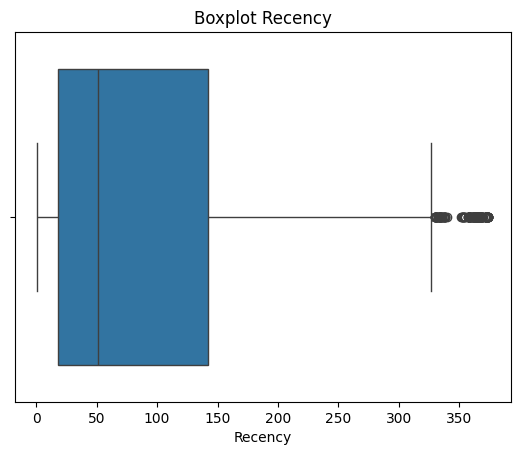

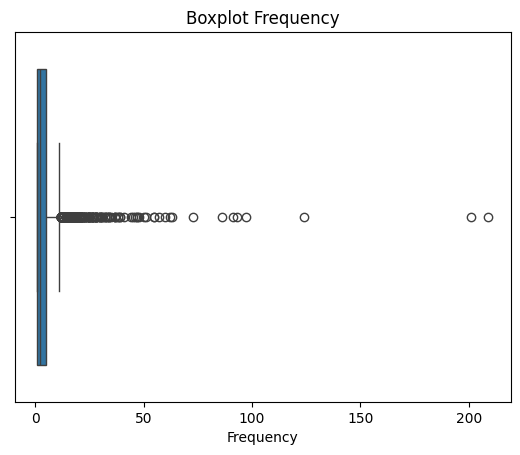

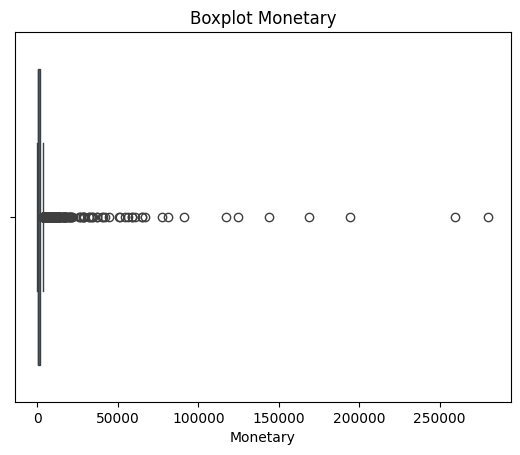

In [31]:
import seaborn as sns

sns.boxplot(x=rfm["Recency"])
plt.title("Boxplot Recency")
plt.show()

sns.boxplot(x=rfm["Frequency"])
plt.title("Boxplot Frequency")
plt.show()

sns.boxplot(x=rfm["Monetary"])
plt.title("Boxplot Monetary")
plt.show()

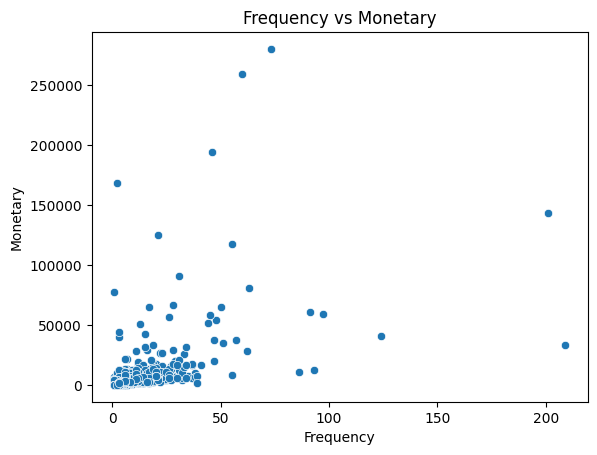

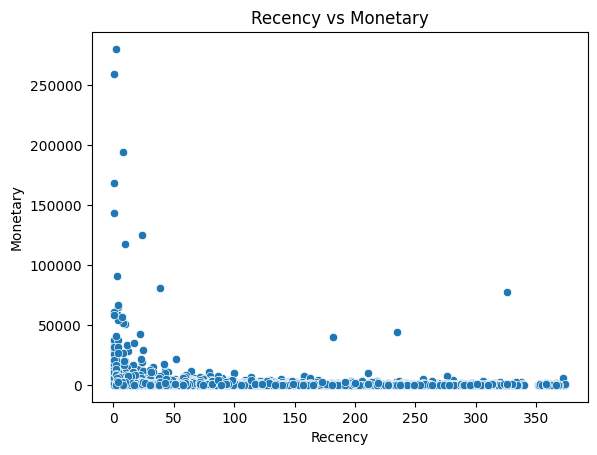

In [32]:
# Frequency vs Monetary
sns.scatterplot(x="Frequency", y="Monetary", data=rfm)
plt.title("Frequency vs Monetary")
plt.show()

# Recency vs Monetary
sns.scatterplot(x="Recency", y="Monetary", data=rfm)
plt.title("Recency vs Monetary")
plt.show()

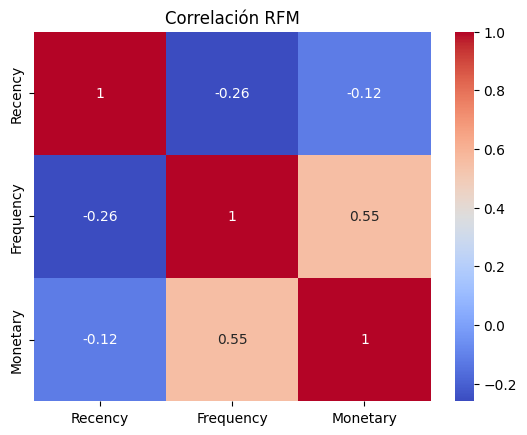

In [33]:
corr = rfm.corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlación RFM")
plt.show()

In [34]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])
rfm["F_score"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1,2,3,4])
rfm["M_score"] = pd.qcut(rfm["Monetary"], 4, labels=[1,2,3,4])

rfm["RFM_Score"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)

print(rfm.head())

            Recency  Frequency  Monetary R_score F_score M_score RFM_Score
CustomerID                                                                
12346.0         326          1  77183.60       1       1       4       114
12347.0           2          7   4310.00       4       4       4       444
12348.0          75          4   1797.24       2       3       4       234
12349.0          19          1   1757.55       3       1       4       314
12350.0         310          1    334.40       1       1       2       112


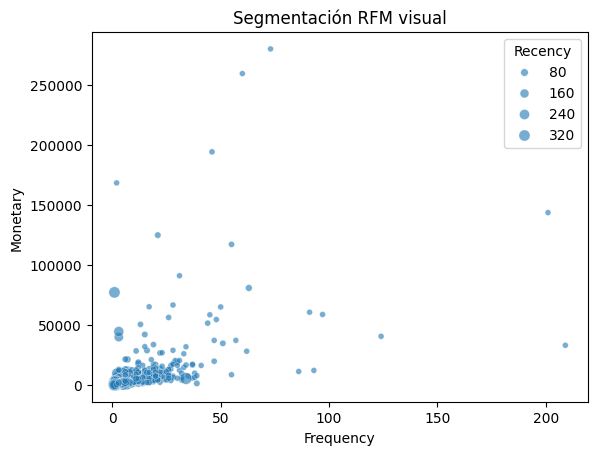

In [35]:
sns.scatterplot(
    x="Frequency",
    y="Monetary",
    size="Recency",
    data=rfm,
    alpha=0.6
)
plt.title("Segmentación RFM visual")
plt.show()